In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()
df=df.drop_duplicates()

In [7]:
print("سن پر تکرار")
df['age'].value_counts().head(10)

سن پر تکرار


age
18    69
19    67
46    29
52    29
50    29
47    29
48    29
51    29
45    29
20    29
Name: count, dtype: int64

In [8]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

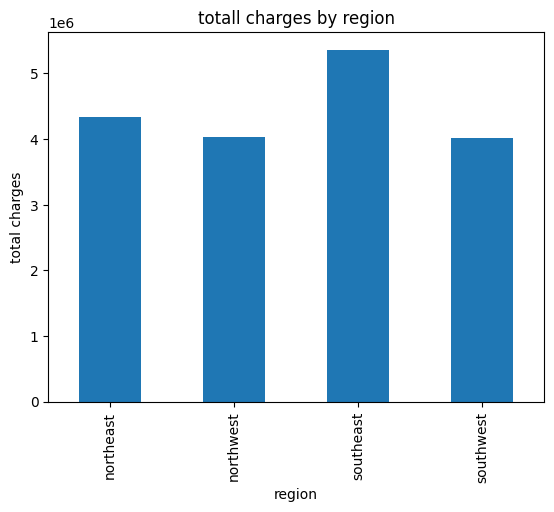

In [9]:
df.groupby("region")['charges'].sum().plot(kind="bar")
plt.title("totall charges by region")
plt.xlabel("region")
plt.ylabel("total charges")
plt.show()

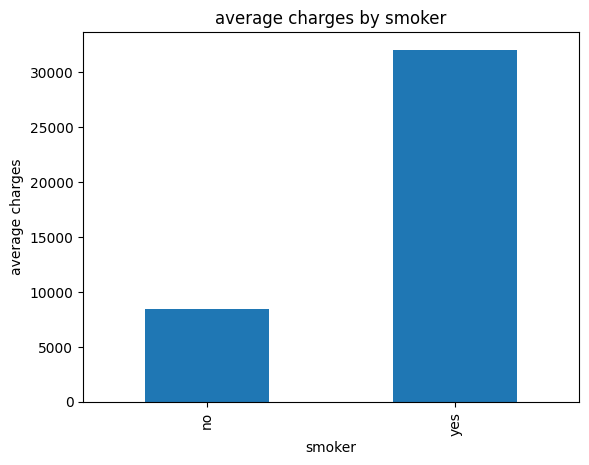

In [10]:
df.groupby("smoker")["charges"].mean().plot(kind="bar")
plt.title("average charges by smoker")
plt.xlabel("smoker")
plt.ylabel("average charges")
plt.show()

In [11]:
encoder=LabelEncoder()
for col in df.columns:
    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

In [12]:
x=df.drop("charges",axis=1)
y=df['charges']

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
models=[LinearRegression(),DecisionTreeRegressor(),RandomForestRegressor(n_estimators=100),KNeighborsRegressor(n_neighbors=5)]

for model in models:
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(r2_score(y_test,y_pred)*100)

80.68466322629111
77.78327679396777
88.34213714424541
4.977435442244904
